In [11]:
print('📋 DETAILED CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(
    all_true_labels,
    all_predictions,
    target_names=class_names
))

📋 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Airplane       0.76      0.82      0.79      1000
         Car       0.81      0.87      0.84      1000
        Bird       0.66      0.67      0.66      1000
         Cat       0.58      0.53      0.55      1000
        Deer       0.67      0.71      0.69      1000
         Dog       0.69      0.62      0.65      1000
        Frog       0.77      0.84      0.81      1000
       Horse       0.76      0.81      0.79      1000
        Ship       0.84      0.86      0.85      1000
       Truck       0.90      0.71      0.80      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



/tmp/ipykernel_14304/221429121.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


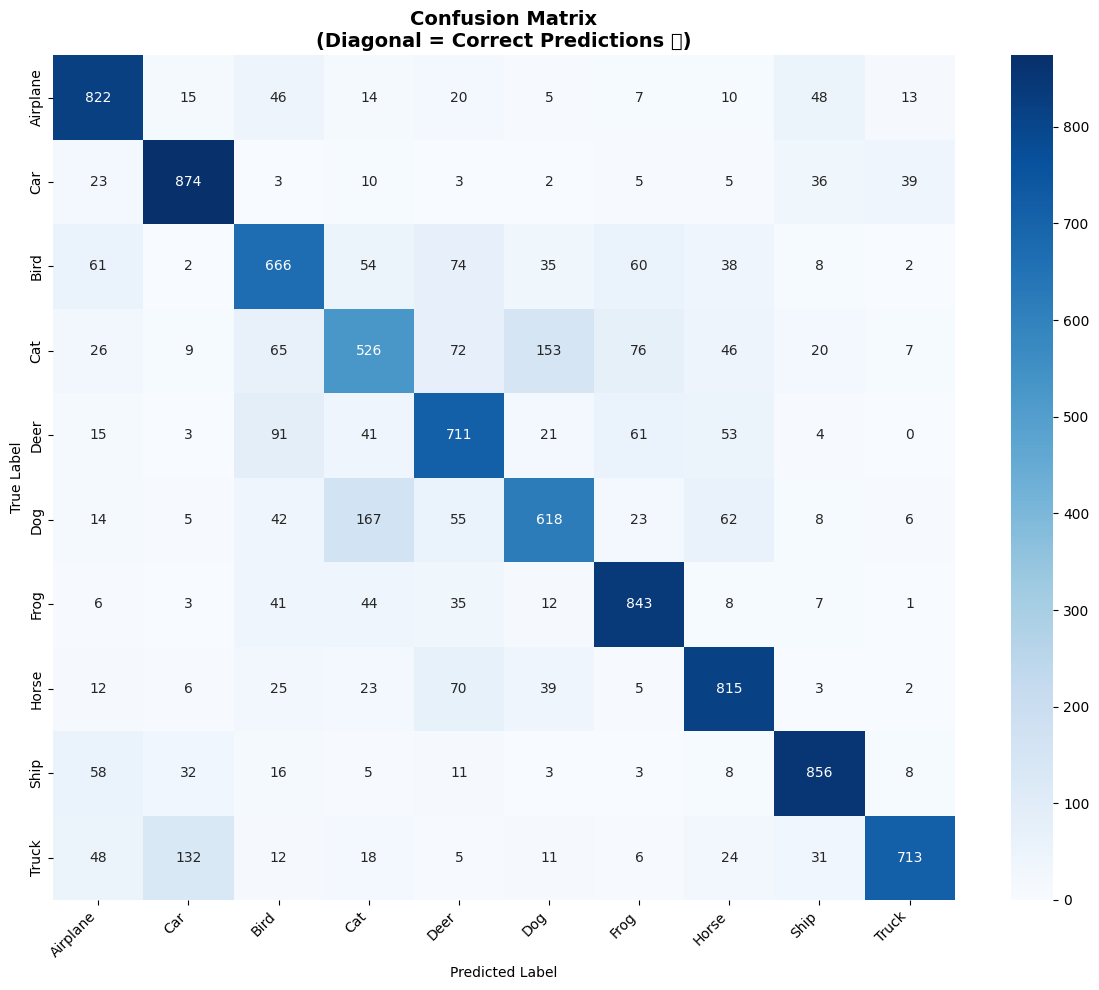

In [10]:
cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix\n(Diagonal = Correct Predictions ✅)',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
accuracy  = accuracy_score(all_true_labels, all_predictions)
precision = precision_score(all_true_labels, all_predictions, average='weighted')
recall    = recall_score(all_true_labels, all_predictions, average='weighted')
f1        = f1_score(all_true_labels, all_predictions, average='weighted')

print('=' * 45)
print('     📊 CNN EVALUATION RESULTS')
print('=' * 45)
print(f'  ✅ Accuracy  : {accuracy  * 100:.2f}%')
print(f'  ✅ Precision : {precision * 100:.2f}%')
print(f'  ✅ Recall    : {recall    * 100:.2f}%')
print(f'  ✅ F1 Score  : {f1        * 100:.2f}%')
print('=' * 45)

     📊 CNN EVALUATION RESULTS
  ✅ Accuracy  : 74.44%
  ✅ Precision : 74.48%
  ✅ Recall    : 74.44%
  ✅ F1 Score  : 74.26%


In [8]:
model.eval()
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs          = model(images)
        _, predicted     = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

print(f'✅ Predictions done for {len(all_predictions)} images!')

✅ Predictions done for 10000 images!


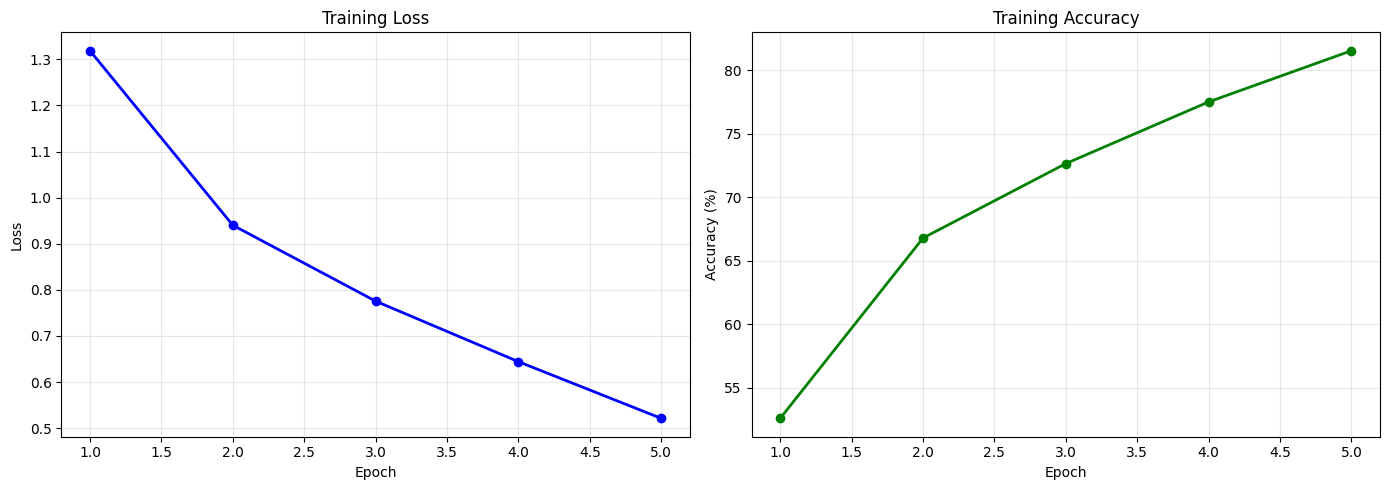

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, num_epochs + 1)

ax1.plot(epochs_range, train_losses, 'b-o', linewidth=2)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accuracies, 'g-o', linewidth=2)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
num_epochs       = 5
train_losses     = []
train_accuracies = []

print('🚀 Training Started...\n')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f'Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%')

print('\n✅ Training Complete!')

🚀 Training Started...

Epoch 1 | Loss: 1.3188 | Accuracy: 52.59%
Epoch 2 | Loss: 0.9402 | Accuracy: 66.79%
Epoch 3 | Loss: 0.7755 | Accuracy: 72.65%
Epoch 4 | Loss: 0.6442 | Accuracy: 77.51%
Epoch 5 | Loss: 0.5212 | Accuracy: 81.53%

✅ Training Complete!


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool    = nn.MaxPool2d(2, 2)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 32x32 → 16x16
        x = self.pool(self.relu(self.conv2(x)))  # 16x16 → 8x8
        x = x.view(-1, 64 * 8 * 8)              # Flatten
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f'🖥️  Device: {device}')
print('✅ Model ready!')

🖥️  Device: cpu
✅ Model ready!


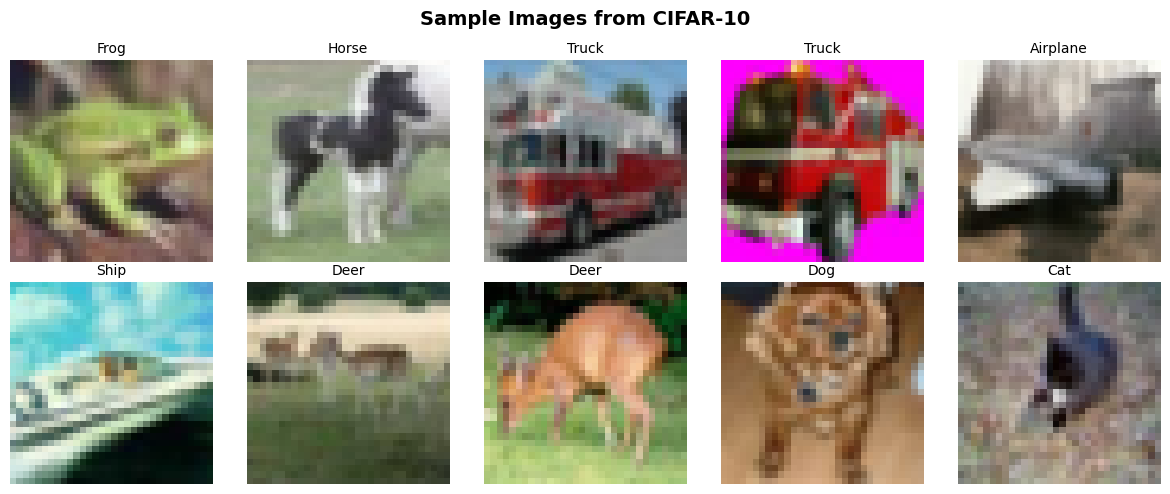

In [4]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Images from CIFAR-10', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5
    img = img.numpy().transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)

class_names = ['Airplane','Car','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

print(f'✅ Training images: {len(train_dataset)}')
print(f'✅ Testing images:  {len(test_dataset)}')

✅ Training images: 50000
✅ Testing images:  10000


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!
